## Sentiment Analysis of IMDB Reviews using LSTM

## Problem Statement

The goal of this project is to build a deep learning model that can automatically classify IMDB movie reviews as positive or negative using Natural Language Processing (NLP) techniques and a Bidirectional LSTM neural network.

# Objective of the Project
* Analyze movie review text data
* Perform EDA on review lengths and sentiments
* Convert text into numerical sequences
* Train a Bidirectional LSTM model
* Predict sentiment accurately

# Why LSTM for IMDB Project?

 Because movie reviews:

* are long sentences
* contain context
* need memory of previous words


LSTM understands full sentence meaning better.

In [37]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

In [38]:
# Load Dataset
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

Sentiment Distribution

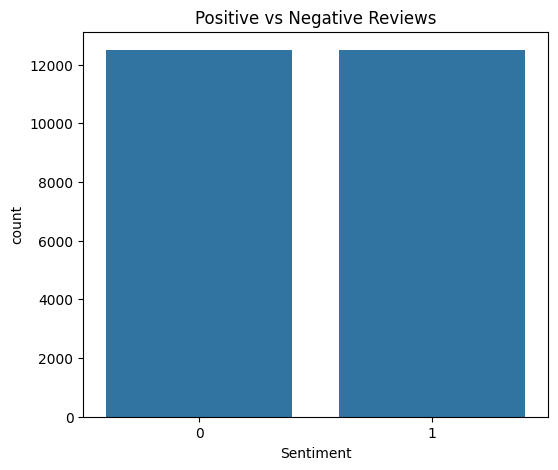

In [39]:
# Shows the number of positive and negative reviews in the dataset.
# Create dataframe
df = pd.DataFrame({
    "Sentiment": y_train
})

# Countplot
plt.figure(figsize=(6,5))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Positive vs Negative Reviews")

plt.show()

Review Length distribution

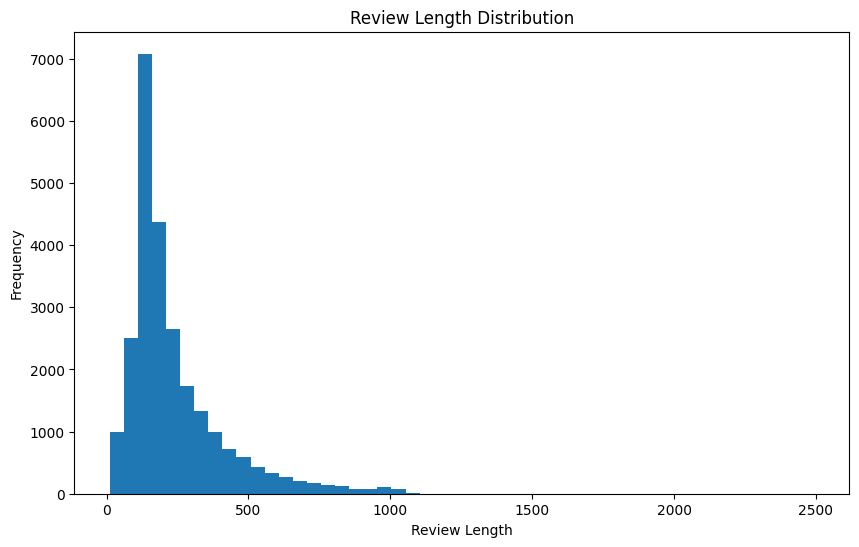

In [40]:
# Displays the distribution of review lengths.
# Calculate review lengths
review_lengths = [len(review) for review in X_train]

# Histogram
plt.figure(figsize=(10,6))

plt.hist(review_lengths, bins=50)

plt.title("Review Length Distribution")

plt.xlabel("Review Length")

plt.ylabel("Frequency")

plt.show()

KDE plot

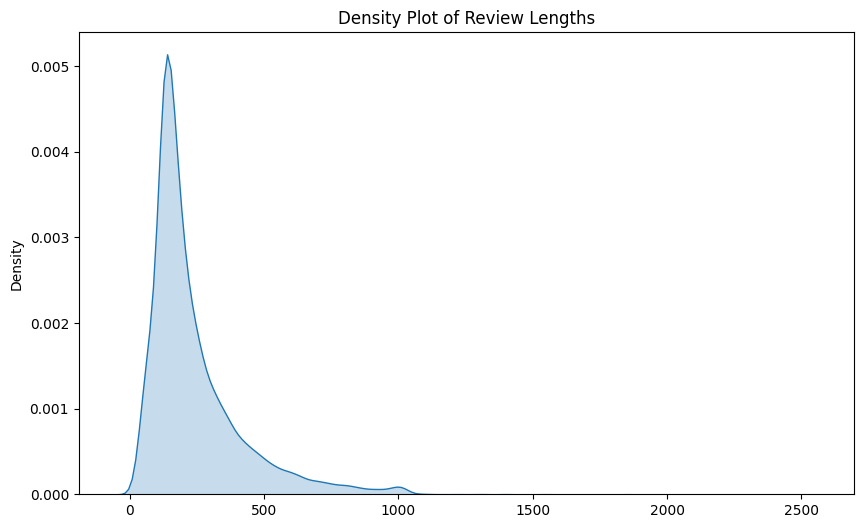

In [41]:
# Visualizes the density and spread of review lengths smoothly.
plt.figure(figsize=(10,6))

sns.kdeplot(
    review_lengths,
    fill=True
)

plt.title("Density Plot of Review Lengths")

plt.show()

In [42]:
# Create Tokenizer
tokenizer = Tokenizer(num_words=vocab_size)

In [43]:
# Padding Sequences
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)


* LSTM remembers important information
* Bidirectional reads sentence:*
* → Left to Right
* → Right to Left

In [44]:
# Build Model
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    )
)

# Bidirectional LSTM Layer
model.add(
    Bidirectional(
        LSTM(64, return_sequences=False)
    )
)

# Dropout Layer
model.add(Dropout(0.5))

# Dense Hidden Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


c:\Users\Aditya Kadam\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


| Layer              | One-Line Description                                                |
| ------------------ | ------------------------------------------------------------------- |
| Embedding Layer    | Converts words into numerical vector representations.               |
| Bidirectional LSTM | Learns sentence meaning from both forward and backward directions.  |
| Dropout Layer      | Prevents overfitting by randomly disabling neurons during training. |
| Dense Layer        | Learns complex patterns from extracted features.                    |
| Output Layer       | Predicts whether the review is positive or negative.                |


In [45]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Early Stopping automatically stops training when the model’s validation performance stops improving to prevent overfitting.

In [46]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 400ms/step - accuracy: 0.6925 - loss: 0.5461 - val_accuracy: 0.8526 - val_loss: 0.3568
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 389ms/step - accuracy: 0.9047 - loss: 0.2515 - val_accuracy: 0.8514 - val_loss: 0.3373
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 405ms/step - accuracy: 0.9389 - loss: 0.1709 - val_accuracy: 0.8690 - val_loss: 0.3513
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 120s 384ms/step - accuracy: 0.9581 - loss: 0.1180 - val_accuracy: 0.8534 - val_loss: 0.3936


In [48]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.8417 - loss: 0.3516

Test Accuracy: 0.8449199795722961


In [49]:
review = ["Movie was fantastic"]

seq = tokenizer.texts_to_sequences(review)
pad = pad_sequences(seq, maxlen=200)

prediction = model.predict(pad)

print("Positive 😊" if prediction[0][0] > 0.5 else "Negative 😔")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Positive 😊


In [50]:
model.save("models/lstm_model.h5")

## IMDB Sentiment Analysis Project Pipeline

1. Import Libraries
        ↓
2. Load IMDB Dataset
        ↓
3. Text Preprocessing
   * Tokenization
   * Sequence Padding
   * Vocabulary Selection
        ↓
4. Train-Test Split
        ↓
5. Build Deep Learning Model
   * Embedding Layer
   * Bidirectional LSTM
   * Dropout Layer
   * Dense Layers
        ↓
6. Compile Model
   * Optimizer
   * Loss Function
   * Accuracy Metric
        ↓
7. Train Model
   * Epochs
   * Batch Size
   * Validation Split
   * Early Stopping
        ↓
8. Model Evaluation
   * Test Accuracy
   * Loss Evaluation
        ↓
9. Make Predictions
   * Positive Review
   * Negative Review
        ↓
10. Final Sentiment Classification Output

# Project Conclusion

This project successfully developed a Bidirectional LSTM deep learning model for IMDB movie review sentiment analysis using NLP techniques. The model effectively classified reviews as positive or negative with high accuracy by applying text preprocessing, tokenization, padding, EDA, and LSTM architecture. The project improved understanding of Deep Learning, Natural Language Processing, and sentiment classification using TensorFlow and Keras.